# Preliminary Data Analysis and Visualization

In [1]:
# Import Chunk
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.stats.inter_rater import fleiss_kappa
import numpy as np

## 1. Load and Prepare Data

In [2]:
# Gold standard dataset (without meta data)
df_gold_raw = pd.read_excel("../data/gold_standard_labels_done.xlsx")

# Full job ad dataset (with metadata)
df_full = pd.read_parquet("../data/job_ads_cleaned.parquet")


### Standardize location to state code

Location names are so far inconsistent. There are several cases, from all of which we extract the state code and store it in a new column
*  Case 1: The state code is given at the end of the string (e.g., Salt Lake City, UT)
*  Case 2: The state name is included somewhere in the string (e.g., Cleveland, Ohio, United States )
*  Case 3: The metropolitain area, but not the state is given (e.g., San Francisco Bay Area)
*  Case 4: Only the country is given 

In [3]:
# Case 1: Extract state codes 

state_codes = [
    "AL", "AK", "AZ", "AR", "CA", "CO", "CT", "DE", "FL", "GA",
    "HI", "ID", "IL", "IN", "IA", "KS", "KY", "LA", "ME", "MD",
    "MA", "MI", "MN", "MS", "MO", "MT", "NE", "NV", "NH", "NJ",
    "NM", "NY", "NC", "ND", "OH", "OK", "OR", "PA", "RI", "SC",
    "SD", "TN", "TX", "UT", "VT", "VA", "WA", "WV", "WI", "WY",
    "DC"
]

pattern = r",\s*(" + "|".join(state_codes) + r")\b"

df_full["state_code"] = df_full["location"].str.extract(pattern, expand=False)

In [4]:
# Case 2: Extract full state name

state_names = {
    "Alabama": "AL",
    "Alaska": "AK",
    "Arizona": "AZ",
    "Arkansas": "AR",
    "California": "CA",
    "Colorado": "CO",
    "Connecticut": "CT",
    "Delaware": "DE",
    "Florida": "FL",
    "Georgia": "GA",
    "Hawaii": "HI",
    "Idaho": "ID",
    "Illinois": "IL",
    "Indiana": "IN",
    "Iowa": "IA",
    "Kansas": "KS",
    "Kentucky": "KY",
    "Louisiana": "LA",
    "Maine": "ME",
    "Maryland": "MD",
    "Massachusetts": "MA",
    "Michigan": "MI",
    "Minnesota": "MN",
    "Mississippi": "MS",
    "Missouri": "MO",
    "Montana": "MT",
    "Nebraska": "NE",
    "Nevada": "NV",
    "New Hampshire": "NH",
    "New Jersey": "NJ",
    "New Mexico": "NM",
    "New York": "NY",
    "North Carolina": "NC",
    "North Dakota": "ND",
    "Ohio": "OH",
    "Oklahoma": "OK",
    "Oregon": "OR",
    "Pennsylvania": "PA",
    "Rhode Island": "RI",
    "South Carolina": "SC",
    "South Dakota": "SD",
    "Tennessee": "TN",
    "Texas": "TX",
    "Utah": "UT",
    "Vermont": "VT",
    "Virginia": "VA",
    "Washington": "WA",
    "West Virginia": "WV",
    "Wisconsin": "WI",
    "Wyoming": "WY",
    "District of Columbia": "DC"
}

for state_name, state_code in state_names.items():
    mask = (
        df_full["state_code"].isna()
        & df_full["location"].str.contains(state_name, case=False, regex=False, na=False)
    )
    df_full.loc[mask, "state_code"] = state_code

In [5]:
# Case 3: Manually map metropolitan areas to states

area_to_state = {
    "Los Angeles Metropolitan Area": "CA",
    "Urbana-Champaign Area": "IL",
    "Greater Sacramento": "CA",
    "San Francisco Bay Area": "CA",
    "Charlotte Metro": "NC",
    "Atlanta Metropolitan Area": "GA",
    "Denver Metropolitan Area": "CO",
    "Omaha Metropolitan Area": "NE",
    "Greater Jackson Area": "MS",
    "Pensacola Metropolitan Area": "FL",
    "Greater Macon": "GA",
    "Greater Charlottesville Area": "VA",
    "Greater Houston": "TX",
    "Blacksburg-Christiansburg-Radford Area": "VA",
    "Greater Roanoke Area": "VA",
    "Greensboro--Winston-Salem--High Point Area": "NC",
    "Greater Minneapolis-St. Paul Area": "MN",
    "Greater Chicago Area": "IL",
    "Greater Hartford": "CT",
    "Greater Phoenix Area": "AZ",
    "Cincinnati Metropolitan Area": "OH",
    "Greater Boston": "MA",
    "Medford-Grants Pass Area": "OR",
    "Salt Lake City Metropolitan Area": "UT",
    "Dallas-Fort Worth Metroplex": "TX",
    "San Diego Metropolitan Area": "CA",
    "South Bend-Mishawaka Region": "IN",
    "Greater St. Louis": "MO",
    "Metro Jacksonville": "FL",
    "Buffalo-Niagara Falls Area": "NY",
    "Lawton Area": "OK",
    "Greater Lansing": "MI",
    "Utica-Rome Area": "NY",
    "Miami-Fort Lauderdale Area": "FL",
    "Greater Yakima Area": "WA",
    "Greater Seattle Area": "WA",
    "Greater Philadelphia": "PA",
    "Greater Richmond Region": "VA",
    "Nashville Metropolitan Area": "TN",
    "Las Vegas Metropolitan Area": "NV",
    "Detroit Metropolitan Area": "MI",
    "Greater Pittsburgh Region": "PA",
    "Waco Area": "TX",
    "Greater New Orleans Region": "LA",
    "Greater Dothan": "AL",
    "Greater Orlando": "FL",
    "Johnson City-Kingsport-Bristol Area": "TN",
    "Raleigh-Durham-Chapel Hill Area": "NC",
    "Greater Chattanooga": "TN",
    "Greater Tampa Bay Area": "FL",
    "Peoria Metropolitan Area": "IL",
    "Tallahassee Metropolitan Area": "FL",
    "Greater Milwaukee": "WI",
    "Knoxville Metropolitan Area": "TN",
    "Baton Rouge Metropolitan Area": "LA",
    "Cape Coral Metropolitan Area": "FL",
    "Greater Jefferson City Area": "MO",
    "Pueblo-Cañon City Area": "CO",
    "Albuquerque-Santa Fe Metropolitan Area": "NM",
    "Grand Rapids Metropolitan Area": "MI",
    "Greater Harrisburg Area": "PA",
    "Little Rock Metropolitan Area": "AR",
    "Greater Fort Wayne": "IN",
    "Greater Morgantown Area": "WV",
    "Greater Asheville": "NC",
    "Greater McAllen Area": "TX",
    "State College-DuBois Area": "PA",
    "Greater Savannah Area": "GA",
    "Des Moines Metropolitan Area": "IA",
    "Greater Cleveland": "OH",
    "Greater Farmington Area": "NM",
    "Greater Kennewick Area": "WA",
    "Greater Bloomington Area": "IN",
    "Greater Sioux Falls Area": "SD",
    "Fargo-Moorhead": "ND",
    "Memphis Metropolitan Area": "TN",
    "Greater Syracuse-Auburn Area": "NY",
    "Greater Reno Area": "NV",
    "Dayton Metropolitan Area": "OH",
    "Greater Missoula Area": "MT",
    "Spokane-Coeur d'Alene Area": "WA",
    "College Station-Bryan Area": "TX",
    "Youngstown-Warren area": "OH",
    "Bowling Green Metropolitan Area": "KY",
    "Greater Tucson Area": "AZ",
    "Greater Hattiesburg Area": "MS",
    "Greater Clarksville Area": "TN",
    "San Angelo Area": "TX",
    "Greater Scranton Area": "PA",
    "Huntsville-Decatur-Albertville Area": "AL",
    "Killeen-Temple Area": "TX",
    "Greater Madison Area": "WI",
    "Greater Wilmington Area": "DE",
    "Erie-Meadville Area": "PA",
    "Greater Rockford Area": "IL",
    "Harrisonburg-Staunton-Waynesboro Area": "VA",
    "Boise Metropolitan Area": "ID",
    "Elmira-Corning Area": "NY",
    "Greater Corpus Christi Area": "TX",
    "Midland-Odessa Area": "TX",
    "Twin Falls Area": "ID",
    "Greater Bangor Area": "ME",
    "Mobile Metropolitan Area": "AL",
    "Crestview-Fort Walton Beach-Destin Area": "FL",
    "Santa Barbara-Santa Maria Area": "CA",
    "Lubbock-Levelland Area": "TX",
    "Greater Fort Collins Area": "CO",
    "Rocky Mount-Wilson Area": "NC",
}

df_full["state_code"] = df_full["state_code"].fillna(df_full["location"].map(area_to_state))

In [6]:
# Case 4: Handle country level information

country_to_state = {
    "United States": "Unknown",
    "Canada": "Non-US",
    "London, England, United Kingdom": "Non-US",
    "Kenya": "Non-US",
    "NAMER": "Non-US",
    "Montreal, QC": "Non-US",
    "Brazil": "Non-US",
    "Honduras": "Non-US",
    "Germany": "Non-US",
    "India": "Non-US",
    "Latin America": "Non-US"
}

df_full["state_code"] = df_full["state_code"].fillna(df_full["location"].map(country_to_state))

In [7]:
# Verify that no further cases are left
print(df_full[df_full["state_code"].isna()])

Empty DataFrame
Columns: [job_id, title, location, formatted_experience_level, listed_date, description, state_code]
Index: []


In [8]:
# Add state name column
state_codes_names = {v: k for k, v in state_names.items()}
state_codes_names.update({"Unknown":"Unknown",
                          "Non-US":"Non-US"})

df_full["state_name"] = df_full["state_code"].map(state_codes_names)

In [9]:
# Save file for labor market analysis 
df_full.to_parquet("../data/job_ads_cleaned_state.parquet")

### Add meta data to gold standard dataset

In [10]:
# Sanity check if job-ad titles match based on job_id between full corpus and gold standard set
print(
    all(
        df_gold_raw.loc[df_gold_raw["job_id"] == id, "title"].iloc[0] 
        == df_full.loc[df_full["job_id"] == id, "title"].iloc[0]
        for id in df_gold_raw["job_id"].to_list()
    )
)

# Left join meta data columns 
df_gold = df_gold_raw.merge(
    df_full[["job_id", "state_code", "state_name", "formatted_experience_level", "listed_date"]],
    on="job_id",
    how="left"
)

True


## 2. Text Length Distribution

In [11]:
# Dataset size
print(
    "Dataset Sizes\n",
    f"Full corpus: {len(df_full)}\n",
    f"Gold standard set: {len(df_gold)}"
)

Dataset Sizes
 Full corpus: 30587
 Gold standard set: 740


In [12]:
# Compute text length
df_full["text_length"] = df_full["description"].str.split().str.len()
df_gold["text_length"] = df_gold["text_final"].str.split().str.len()

# Descriptives
print("Full corpus\n", df_full["text_length"].describe())
print("\nGold standard set\n", df_gold["text_length"].describe())

Full corpus
 count    30587.000000
mean       499.532514
std        294.653776
min          1.000000
25%        281.000000
50%        455.000000
75%        669.000000
max       2893.000000
Name: text_length, dtype: float64

Gold standard set
 count     740.000000
mean      497.706757
std       286.387819
min         5.000000
25%       292.000000
50%       446.000000
75%       664.500000
max      2307.000000
Name: text_length, dtype: float64


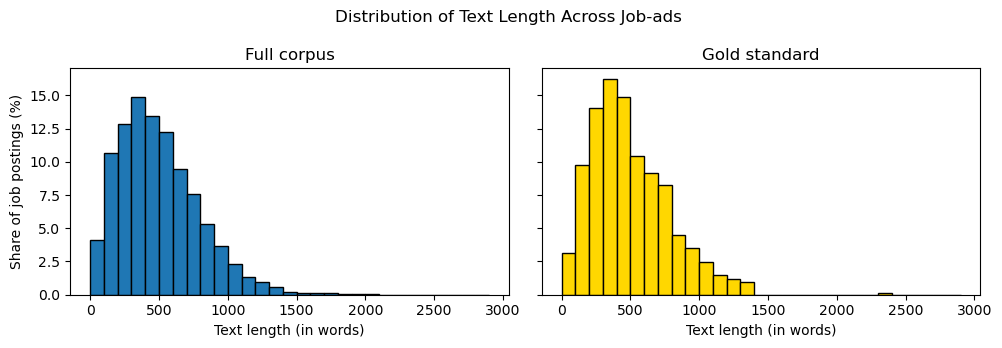

In [13]:
# Visualize 
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), sharey=True)

# Same bins for both datasets
max_length = max(
    df_full["text_length"].max(),
    df_gold["text_length"].max()
)

bins = range(0, int(max_length) + 100, 100)

# Full corpus
axes[0].hist(
    df_full["text_length"],
    bins=bins,
    weights=[100 / len(df_full)] * len(df_full),
    edgecolor="black"
)

axes[0].set_title("Full corpus")
axes[0].set_xlabel("Text length (in words)")
axes[0].set_ylabel("Share of job postings (%)")

# Gold standard
axes[1].hist(
    df_gold["text_length"],
    bins=bins,
    weights=[100 / len(df_gold)] * len(df_gold),
    color="gold",
    edgecolor="black"
)

axes[1].set_title("Gold standard")
axes[1].set_xlabel("Text length (in words)")

fig.suptitle("Distribution of Text Length Across Job-ads")

plt.tight_layout()
plt.show()

## 3. Temporal Distribution

In [14]:
# Time period 
print(
    f"From: {df_full["listed_date"].min()}\n",
    f"To: {df_full["listed_date"].max()}"
)

From: 2023-08-10 12:20:00
 To: 2023-11-04 23:20:00


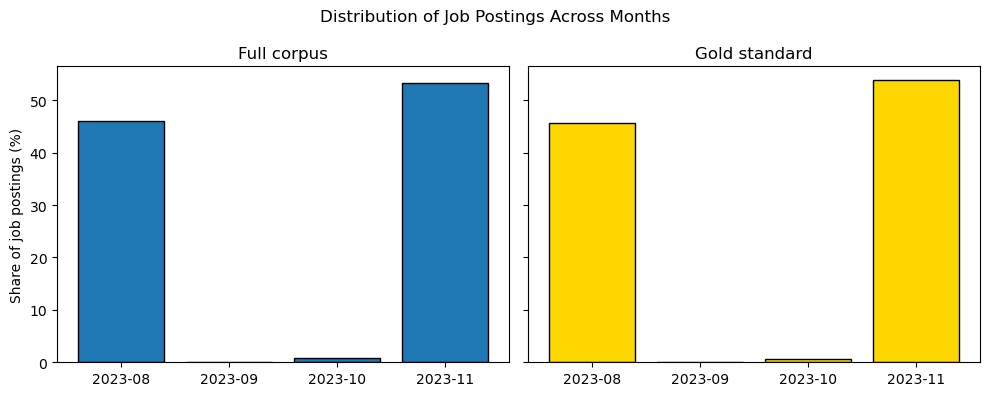

In [15]:
# Monthly shares
months = ["2023-08", "2023-09", "2023-10", "2023-11"]
month_index = pd.PeriodIndex(months, freq="M")
monthly_full = (
    df_full
    .groupby(df_full["listed_date"].dt.to_period("M"))
    .size()
    .reindex(month_index, fill_value=0)
)

monthly_gold = (
    df_gold
    .groupby(df_gold["listed_date"].dt.to_period("M"))
    .size()
    .reindex(month_index, fill_value=0)
)

monthly_full = monthly_full / monthly_full.sum() * 100
monthly_gold = monthly_gold / monthly_gold.sum() * 100

# Convert index to strings
monthly_full.index = monthly_full.index.astype(str)
monthly_gold.index = monthly_gold.index.astype(str)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

# Full corpus
axes[0].bar(monthly_full.index, monthly_full.values, edgecolor="black")
axes[0].set_title("Full corpus")
axes[0].set_ylabel("Share of job postings (%)")

# Gold standard
axes[1].bar(monthly_gold.index, monthly_gold.values,color="gold", edgecolor="black")
axes[1].set_title("Gold standard")

plt.suptitle("Distribution of Job Postings Across Months")
plt.tight_layout()
plt.show()

## 4. Geographical Distribution (State Level)

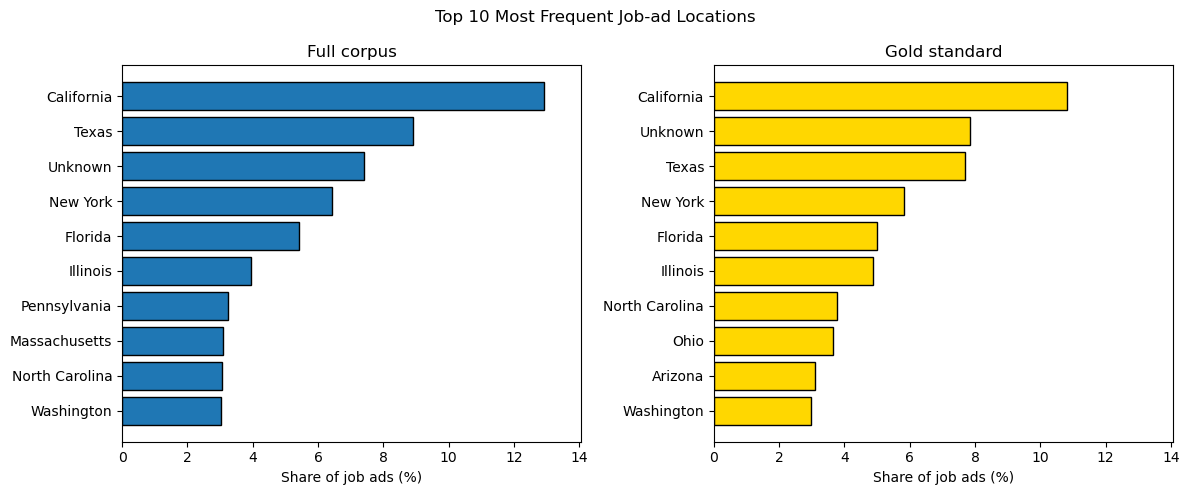

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True)

plt.suptitle("Top 10 Most Frequent Job-ad Locations")

for ax, df, title in zip(
    axes,
    [df_full, df_gold],
    ["Full corpus", "Gold standard"]
):
    
    top10 = (
        df["state_name"]
        .value_counts(normalize=True)
        .head(10)
        .sort_values()
        * 100
    )

    color = "gold" if title == "Gold standard" else None

    ax.barh(
        top10.index,
        top10.values,
        color=color,
        edgecolor="black"
    )

    ax.set_title(title)
    ax.set_xlabel("Share of job ads (%)")
    ax.set_xlim(0, top10.max() * 1.3)

plt.tight_layout()
plt.show()

## 5. ISCO-08 Major Group Distribution

In [17]:
# Prepare data

major_groups = (
    df_gold["isco"]
    .astype(str)
    .str.zfill(3)
    .str[0]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

major_titles = {
    "0": "Armed forces occupations",
    "1": "Managers",
    "2": "Professionals",
    "3": "Technicians and associate professionals",
    "4": "Clerical support workers",
    "5": "Service and sales workers",
    "6": "Skilled agricultural, forestry and fishery workers",
    "7": "Craft and related trades workers",
    "8": "Plant and machine operators, and assemblers",
    "9": "Elementary occupations"
}

major_groups_table = pd.DataFrame({
    "ISCO Major Group": major_groups.index,
    "Title": [major_titles[code] for code in major_groups.index],
    "Share (%)": major_groups.values
})

major_groups_table

,ISCO Major Group,Title,Share (%)
0,1,Managers,15.540541
1,2,Professionals,43.648649
2,3,Technicians and associate professionals,19.189189
3,4,Clerical support workers,5.675676
4,5,Service and sales workers,6.621622
5,6,"Skilled agricultural, forestry and fishery wor...",0.135135
6,7,Craft and related trades workers,4.054054
7,8,"Plant and machine operators, and assemblers",2.432432
8,9,Elementary occupations,2.702703


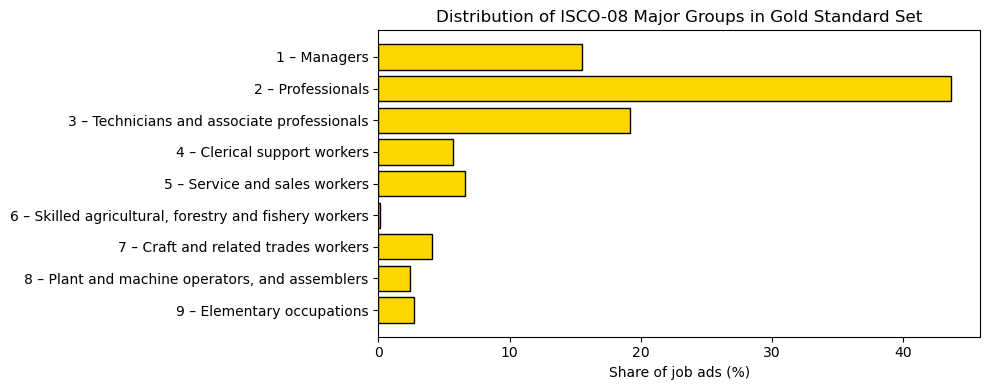

In [18]:
# Visualization

labels = (
    major_groups_table["ISCO Major Group"].astype(str)
    + " – "
    + major_groups_table["Title"]
)

fig, ax = plt.subplots(figsize=(10, 4))

ax.barh(
    labels,
    major_groups_table["Share (%)"],
    color="gold",
    edgecolor="black"
)

ax.invert_yaxis()

ax.set_xlabel("Share of job ads (%)")
ax.set_title("Distribution of ISCO-08 Major Groups in Gold Standard Set")

plt.tight_layout()
plt.show()

In [19]:
# Exact frequencies
df_gold["isco"].astype(str).str[0].value_counts().sort_index()

isco
1    115
2    323
3    142
4     42
5     49
6      1
7     30
8     18
9     20
Name: count, dtype: int64

## 6. Inter-Rater Agreement

In [20]:
# Prepare data

annotator_cols = [
    "isco_Lars",
    "isco_Leander",
    "isco_Philipp",
    "isco_Leon"
]

levels = {
    "Level 1": 1,
    "Level 2": 2,
    "Level 3": 3
}

In [21]:
# Agreement percentages per ISCO level 

results = {}

for level_name, n_digits in levels.items():
    
    agreement_counts = {"3/3": 0, "2/3": 0, "1/3": 0}
    
    for _, row in df_gold[annotator_cols].iterrows():
        
        codes = row.dropna().astype(str).str[:n_digits].tolist()  # only the 3 out of 4 annotations that are present
        
        counts = pd.Series(codes).value_counts()
        max_count = counts.iloc[0]
        
        if max_count == 3:
            agreement_counts["3/3"] += 1
        elif max_count == 2:
            agreement_counts["2/3"] += 1
        elif max_count == 1:
            agreement_counts["1/3"] += 1
    
    total = sum(agreement_counts.values())
    
    results[level_name] = {key: value / total * 100 for key, value in agreement_counts.items()}

agreement_table = pd.DataFrame(results).T[["3/3", "2/3", "1/3"]]

agreement_table.style.format("{:.2f}%")

,3/3,2/3,1/3
Level 1,73.38%,24.46%,2.16%
Level 2,64.86%,30.95%,4.19%
Level 3,55.95%,36.22%,7.84%


In [22]:
# Fleiss Kappa 

kappa_results = {}

for level_name, n_digits in levels.items():

    all_codes = set() # categories occurring at this level

    for col in annotator_cols:
        all_codes.update(
            df_gold[col]
            .dropna()
            .astype(str)
            .str[:n_digits]
        )

    all_codes = sorted(all_codes)


    agreement_matrix = [] # one row per ad, one column per category

    for _, row in df_gold[annotator_cols].iterrows():
        codes = row.dropna().astype(str).str[:n_digits].tolist()
        counts = {code: 0 for code in all_codes}
        for code in codes:
            counts[code] += 1
        agreement_matrix.append([counts[code] for code in all_codes])

    agreement_matrix = np.array(agreement_matrix)
    kappa = fleiss_kappa(agreement_matrix)
    kappa_results[level_name] = kappa

kappa_results

{'Level 1': np.float64(0.7483975617064514),
 'Level 2': np.float64(0.7322596461122248),
 'Level 3': np.float64(0.6705453496562693)}

In [23]:
# Inspect cases with no agreement between annotators (labeled "check" during processing)

check_ads = df_gold[df_gold["isco_final"] == "check"] # 

for _, row in check_ads.iterrows():
    print("=" * 100)
    print(f"TITLE: {row['title']}\n")
    print("VOTES:")
    for col in annotator_cols:
        if pd.notna(row[col]):
            print(f"  {col}: {row[col]}")
    print(f"\nFINALE VOTE: {row['isco']}")
    print("-" * 100)
    print(row["text_final"])
    print("\n")

TITLE: Senior Preconstruction Estimator - Data Center Construction

VOTES:
  isco_Lars: 216.0
  isco_Leander: 214.0
  isco_Leon: 311.0

FINALE VOTE: 214.0
----------------------------------------------------------------------------------------------------
Company Description From the inception of a project through to completion and beyond, [ORG] help to deliver the outcomes that matter through transformational programs covering the full spectrum of consultancy, project delivery and post-project operations. With offices located globally, you're never far away from our services. Working from 118 offices in 50 countries, we make the difference to projects across the real estate, infrastructure and natural resources sectors worldwide. Our team is dynamic, innovative and client-focused, supported by an inclusive and fun company culture. Our clients value our proactive approach, depth of expertise, integrity and the quality we deliver. As a result, our people get to enjoy working on some of 